## Markov chain Monte Carlo in the TrueSkill model

In [1]:
import os
import os.path

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from scipy.stats import norm
import scipy.io
import scipy.stats
import torch
import random
from torch.distributions.normal import Normal

from functools import partial

import matplotlib.pyplot as plt

import wget

Implementing the TrueSkill Model

In [2]:
def log_joint_prior(zs_array):
  N = zs_array.shape[1]
  k_array = np.diag(zs_array @ zs_array.T)
  return -N * np.log(2 * np.pi) / 2 - k_array / 2

In [3]:
def logp_a_beats_b(z_a, z_b):
  log_term = torch.logaddexp(z_a, z_b)
  return z_a - log_term  # the result is obtained by simple algebra

def logp_b_beats_a(z_a, z_b):
  log_term = torch.logaddexp(z_b, z_a)
  return z_b - log_term

Examining the posterior for only two players and toy data

In [4]:
def plot_isocontours(ax, func, steps=100):
    x = torch.linspace(-4, 4, steps=steps)
    y = torch.linspace(-4, 4, steps=steps)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    Z = func(X, Y)
    cs = plt.contour(X, Y, Z )
    plt.clabel(cs, inline=1, fontsize=10)
    ax.set_yticks([])
    ax.set_xticks([])

def plot_2d_fun(f, x_axis_label="", y_axis_label="", scatter_pts=None):
    fig = plt.figure(figsize=(8,8), facecolor='white')
    ax = fig.add_subplot(111, frameon=False)
    ax.set_xlabel(x_axis_label)
    ax.set_ylabel(y_axis_label)
    plot_isocontours(ax, f)
    if scatter_pts is not None:
      plt.scatter(scatter_pts[:,0], scatter_pts[:, 1])
    plt.plot([4, -4], [4, -4], 'b--')
    plt.show(block=True)
    plt.draw()

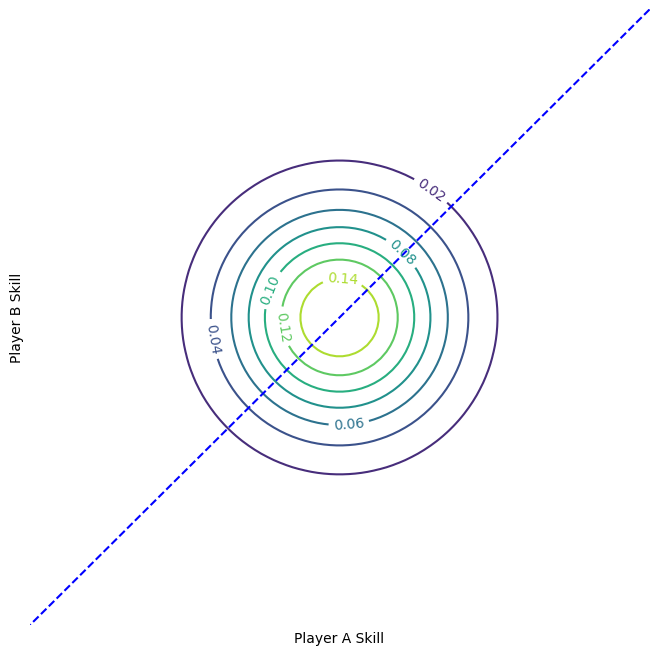

<Figure size 640x480 with 0 Axes>

In [5]:
def log_prior_over_2_players(z1, z2):
  if isinstance(z1, torch.Tensor):
    z1_np = z1.detach().numpy()
  else:
    z1_np = np.array(z1)

  if isinstance(z2, torch.Tensor):
    z2_np = z2.detach().numpy()
  else:
    z2_np = np.array(z2)

  flat = np.stack([z1_np.ravel(),z2_np.ravel()], axis=1)
  log_prior = log_joint_prior(flat)
  return torch.tensor(log_prior.reshape(z1_np.shape))

def prior_over_2_players(z1, z2):
  return torch.exp(log_prior_over_2_players(z1, z2))

plot_2d_fun(prior_over_2_players, "Player A Skill", "Player B Skill")

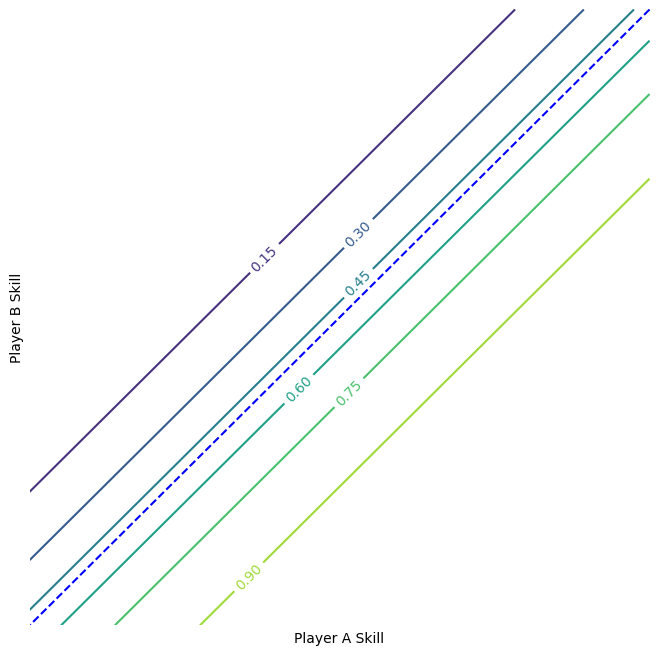

<Figure size 640x480 with 0 Axes>

In [6]:
def likelihood_over_2_players(z1, z2):
  return torch.exp(logp_a_beats_b(z1, z2))

plot_2d_fun(likelihood_over_2_players, "Player A Skill", "Player B Skill")

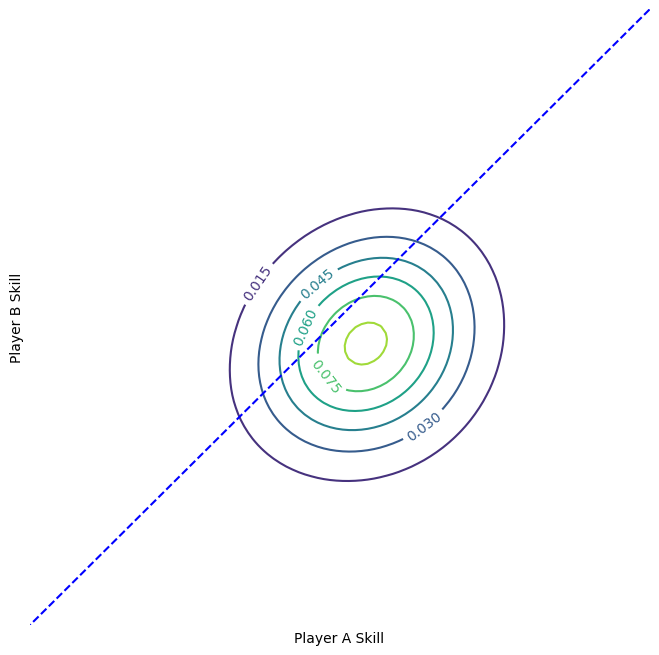

<Figure size 640x480 with 0 Axes>

In [7]:
def log_posterior_A_beat_B(z1, z2):
  log_lik = logp_a_beats_b(z1, z2)
  log_prior = log_prior_over_2_players(z1, z2)
  return log_lik + log_prior

def posterior_A_beat_B(z1, z2):
  return torch.exp(log_posterior_A_beat_B(z1, z2))

plot_2d_fun(posterior_A_beat_B, "Player A Skill", "Player B Skill")

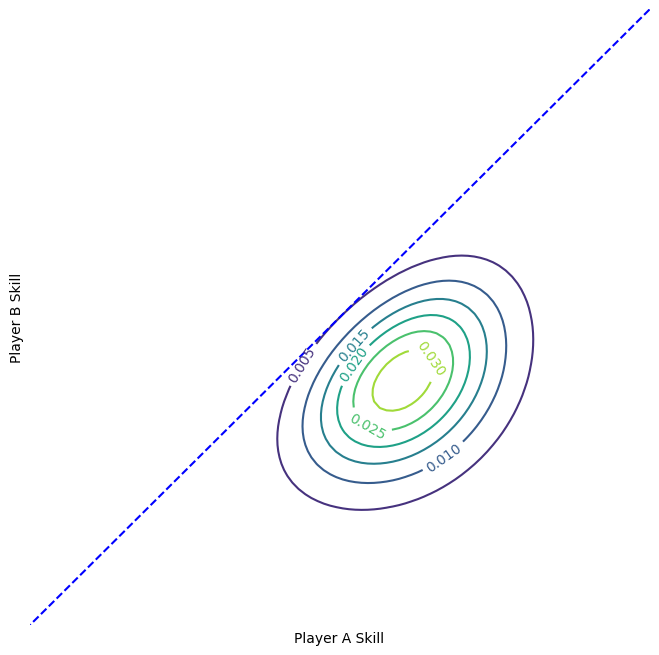

<Figure size 640x480 with 0 Axes>

In [8]:
def log_posterior_A_beat_B_5_times(z1, z2):
  log_lik = logp_a_beats_b(z1, z2)
  log_prior = log_prior_over_2_players(z1, z2)
  return 5 * log_lik + log_prior

def posterior_A_beat_B_5_times(z1, z2):
  return torch.exp(log_posterior_A_beat_B_5_times(z1, z2))

plot_2d_fun(posterior_A_beat_B_5_times, "Player A Skill", "Player B Skill")

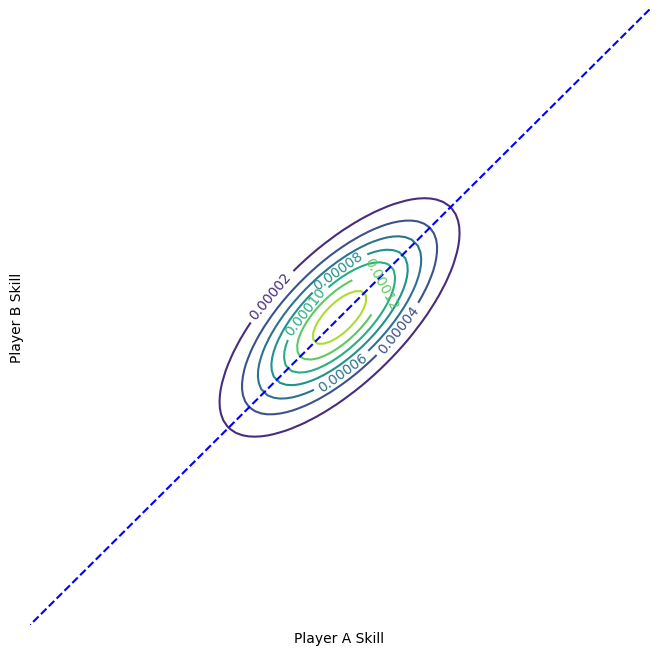

<Figure size 640x480 with 0 Axes>

In [9]:
def log_posterior_beat_each_other_5_times(z1, z2):
  log_lik_a_beats_b = logp_a_beats_b(z1, z2)
  log_lik_b_beats_a = logp_b_beats_a(z1, z2)
  log_prior = log_prior_over_2_players(z1, z2)
  return 5 * log_lik_a_beats_b + 5 * log_lik_b_beats_a + log_prior

def posterior_beat_each_other_5_times(z1, z2):
  return torch.exp(log_posterior_beat_each_other_5_times(z1, z2))

plot_2d_fun(posterior_beat_each_other_5_times, "Player A Skill", "Player B Skill")

Hamiltonian Monte Carlo on Two Players and Toy Data

In [10]:
random.seed(42)
torch.manual_seed(42)

In [11]:
from tqdm import trange, tqdm_notebook

def leapfrog(params_t0, momentum_t0, stepsize, logprob_grad_fun):
  momentum_thalf = momentum_t0    + 0.5 * stepsize * logprob_grad_fun(params_t0)
  params_t1 =      params_t0      +       stepsize * momentum_thalf
  momentum_t1 =    momentum_thalf + 0.5 * stepsize * logprob_grad_fun(params_t1)
  return params_t1, momentum_t1


def iterate_leapfrogs(theta, v, stepsize, num_leapfrog_steps, grad_fun):
  for i in range(0, num_leapfrog_steps):
    theta, v = leapfrog(theta, v, stepsize, grad_fun)
  return theta, v

def metropolis_hastings(state1, state2, log_posterior):
  accept_prob = torch.exp(log_posterior(state2) - log_posterior(state1))
  if random.random() < accept_prob:
    return state2
  else:
    return state1

def draw_samples(num_params, stepsize, num_leapfrog_steps, n_samples, log_posterior):
    theta = torch.zeros(num_params)

    def log_joint_density_over_params_and_momentum(state):
        params, momentum = state
        m = Normal(0., 1.)
        return m.log_prob(momentum).sum(axis=-1) + log_posterior(params)
    
    def grad_fun(zs):
        zs = zs.detach().clone()
        zs.requires_grad_(True)
        y = log_posterior(zs)
        y.backward()
        return zs.grad
    
    sampleslist = []
    for i in trange(0, n_samples):
        sampleslist.append(theta)
    
        momentum = torch.normal(0, 1, size = np.shape(theta))
    
        theta_new, momentum_new = iterate_leapfrogs(theta, momentum, stepsize, num_leapfrog_steps, grad_fun)
    
        theta, momentum = metropolis_hastings((theta, momentum), (theta_new, momentum_new), log_joint_density_over_params_and_momentum)
    return torch.stack((sampleslist))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:29<00:00, 84.13it/s]


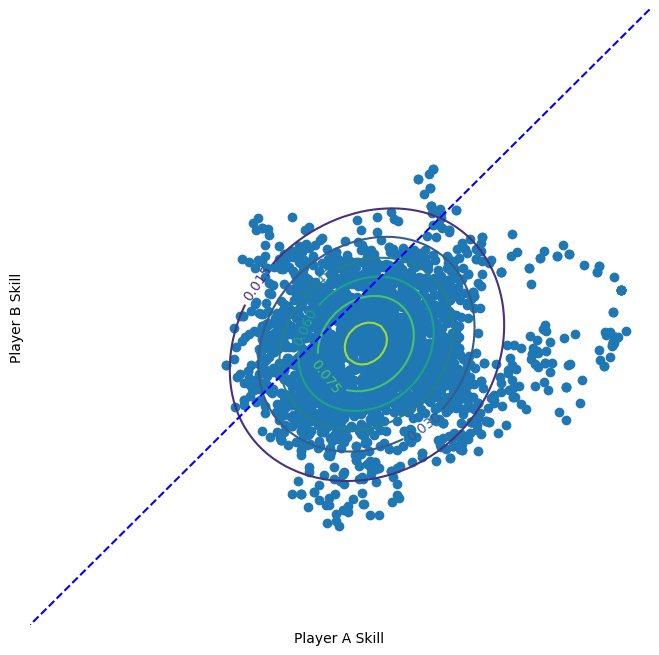

<Figure size 640x480 with 0 Axes>

In [12]:
# Hyperparameters
num_players = 2
num_leapfrog_steps = 20
n_samples = 2500
stepsize = 0.01

def log_posterior_a(zs):
  z1, z2 = zs[0], zs[1]
  return log_posterior_A_beat_B(z1, z2)

samples_a = draw_samples(num_players, stepsize, num_leapfrog_steps, n_samples, log_posterior_a)
plot_2d_fun(posterior_A_beat_B, "Player A Skill", "Player B Skill", samples_a)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:35<00:00, 70.38it/s]


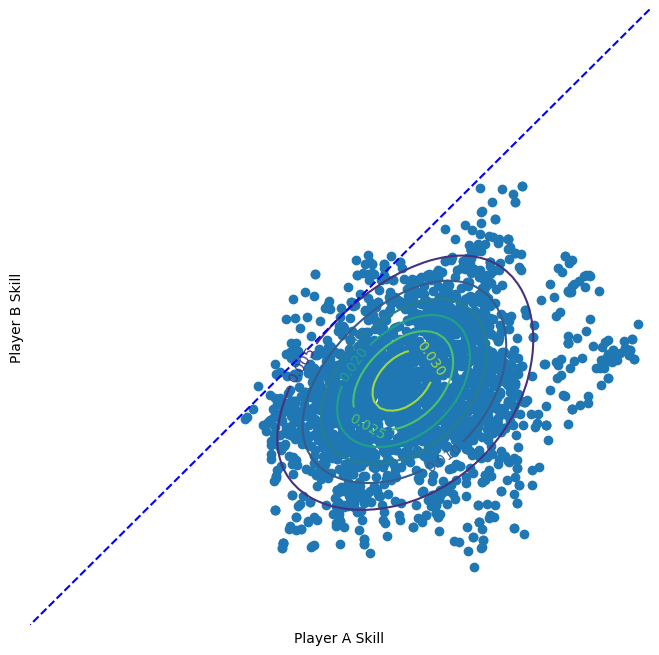

<Figure size 640x480 with 0 Axes>

In [13]:
# Hyperparameters
num_players = 2
num_leapfrog_steps = 20
n_samples = 2500
stepsize = 0.01
key = 42


def log_posterior_b(zs):
  z1, z2 = zs[0], zs[1]
  return log_posterior_A_beat_B_5_times(z1, z2)

sample_b = draw_samples(num_players, stepsize, num_leapfrog_steps, n_samples, log_posterior_b)
plot_2d_fun(posterior_A_beat_B_5_times, "Player A Skill", "Player B Skill", sample_b)

Approximate inference conditioned on real data

In [14]:
wget.download("https://vahidbalazadeh.me/assets/datasets/chess_players.csv")
wget.download("https://vahidbalazadeh.me/assets/datasets/chess_games.csv")
games = pd.read_csv("chess_games.csv")[["winner_id", "loser_id"]].to_numpy()
names = pd.read_csv("chess_players.csv")[["player_name"]].to_numpy().astype('str')

100% [..............................................................................] 20722 / 20722

In [15]:
games = torch.LongTensor(games)

In [16]:
def log_games_likelihood(zs, games):
  winning_player_ixs = games[:,0]
  losing_player_ixs = games[:,1]
  winning_player_skills = zs[winning_player_ixs]   
  losing_player_skills = zs[losing_player_ixs]    
  log_likelihoods = logp_a_beats_b(winning_player_skills, losing_player_skills) 
  return log_likelihoods.sum()                     


In [17]:
def log_joint_probability(zs, games):
  log_prior = -0.5 * zs.numel() * torch.log(torch.tensor(2 * np.pi)) - 0.5 * torch.sum(zs ** 2)
  return log_games_likelihood(zs, games) + log_prior

In [18]:
# Hyperparameters
num_players = 1163
num_leapfrog_steps = 5
n_samples = 1000
stepsize = 0.01

def log_posterior(zs):
  return log_joint_probability(zs, games)

all_games_samples = draw_samples(num_players, stepsize, num_leapfrog_steps, n_samples, log_posterior)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 196.44it/s]


<ErrorbarContainer object of 3 artists>

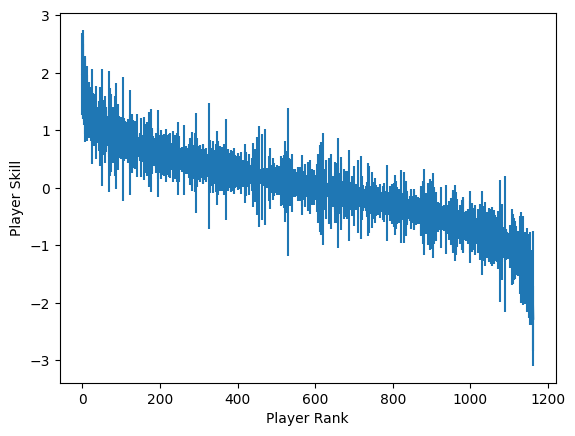

In [19]:
mean_skills = all_games_samples.mean(dim=0)
var_skills = all_games_samples.var(dim=0)

sort_idx = torch.argsort(mean_skills, descending=True)
mean_skills_sorted = mean_skills[sort_idx].numpy()
var_skills_sorted = var_skills[sort_idx].numpy()

plt.xlabel("Player Rank")
plt.ylabel("Player Skill")
plt.errorbar(range(num_players), mean_skills_sorted, var_skills_sorted)

In [20]:
print("Bottom 5")
sort = mean_skills.argsort()
index_bottom = sort[:5]
print(names[index_bottom])

print("Top 5")
index_top = sort[-5:]
print(names[index_top])

Bottom 5
[['thebestofthebad']
 ['vkmansftw']
 ['theking1234']
 ['schoonied']
 ['campionesv']]
Top 5
[['saitama_opm']
 ['nork']
 ['gmanderson']
 ['moistvonlipwig']
 ['doraemon61']]


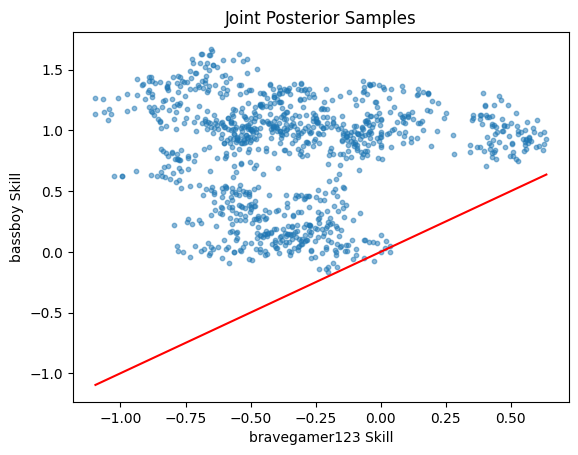

In [21]:
p1 = np.where(names == "bravegamer123")[0][0]
p2 = np.where(names == "bassboy")[0][0]

p1_sample = all_games_samples[:, p1].numpy()
p2_sample = all_games_samples[:, p2].numpy()

plt.scatter(p1_sample, p2_sample, alpha=0.5, s=10)
plt.plot([p1_sample.min(), p1_sample.max()],
         [p1_sample.min(), p1_sample.max()],
         color="r", linestyle="-")
plt.xlabel("bravegamer123 Skill")
plt.ylabel("bassboy Skill")
plt.title("Joint Posterior Samples")
plt.show()